# Assessing Fairness in Bandit Algorithms

This notebook compares **baseline bandits** (UCB1, LinUCB) to **fairness-aware variants** (δ-fair bandit, FairLinUCB\_DP) on two public datasets:
- **Adult** (income prediction)
- **COMPAS** (two-year recidivism)

## 1) Imports, configuration

Set `RUN_MODE = "dev"` for fast iterations (short, fewer seeds).  
Set `RUN_MODE = "full"` to reproduce real results (longer, ≥10 seeds).


In [1]:
from __future__ import annotations

import io
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import confusion_matrix
from IPython.display import display

# RUN MODE
RUN_MODE: str = "dev"

logger = logging.getLogger("fair-bandits")
if not logger.handlers:
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")


@dataclass(frozen=True)
class Config:
    run_mode: str = "dev"
    seed0: int = 42

    # Output / cache
    cache_dir: Path = Path("data_cache")
    results_dir: Path = Path("results")

    # Experiment
    T_group_bandit: int = 50_000      # Exp A
    T_contextual: int = 30_000        # Exp B
    n_seeds: int = 10                 # >= 10
    delta_fair: float = 0.05
    alpha_linucb: float = 1.5
    lambda_ridge: float = 1.0
    dp_tau: float = 0.02
    dp_lambda: float = 2.0

    compas_hash_features: int = 512   # dev can use 256; full can use 512/1024
    n_bootstrap: int = 300            


def build_cfg(run_mode: str) -> Config:
    run_mode = str(run_mode).lower().strip()
    if run_mode not in {"dev", "full"}:
        raise ValueError("RUN_MODE must be 'dev' or 'full'")

    if run_mode == "dev":
        cfg = Config(
            run_mode="dev",
            results_dir=Path("results") / "dev",
            T_group_bandit=10_000,
            T_contextual=5_000,
            n_seeds=3,
            compas_hash_features=256,
            n_bootstrap=200,
        )
    else:
        cfg = Config(
            run_mode="full",
            results_dir=Path("results") / "full",
            T_group_bandit=50_000,
            T_contextual=30_000,
            n_seeds=10,
            compas_hash_features=512,
            n_bootstrap=1000,
        )

    cfg.results_dir.mkdir(parents=True, exist_ok=True)
    cfg.cache_dir.mkdir(parents=True, exist_ok=True)
    return cfg


CFG = build_cfg(RUN_MODE)
print("RUN_MODE =", CFG.run_mode)
print("results_dir =", CFG.results_dir.resolve())


RUN_MODE = dev
results_dir = C:\Users\jmjn\Desktop\MA2\thesis\JM-Git\Fairness-JM-JN\results\dev


## 2) Dataset loaders

We use public loaders with local caching:
- Adult via `fetch_openml`
- COMPAS via ProPublica's released CSV (download-once)


In [2]:
import urllib.request

ADULT_NAME = "adult"  # OpenML name
COMPAS_URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"


def _download_bytes(url: str) -> bytes:
    with urllib.request.urlopen(url) as r:
        return r.read()


def load_adult(cache_dir: Optional[Path] = None) -> pd.DataFrame:
    """Load Adult (OpenML) as a pandas DataFrame."""
    X, y = fetch_openml(ADULT_NAME, version=2, as_frame=True, return_X_y=True)
    df = X.copy()
    df["income"] = y
    return df


def load_compas(cache_dir: Optional[Path] = None) -> pd.DataFrame:
    """Download-once loader for COMPAS (public CSV)."""
    cache_dir = cache_dir or CFG.cache_dir
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / "compas-scores-two-years.csv"
    if not path.exists():
        logger.info("Downloading COMPAS dataset...")
        path.write_bytes(_download_bytes(COMPAS_URL))
    return pd.read_csv(path)


## 3) Fairness metrics + label normalization

- **Utility**: accuracy (contextual bandit) or cumulative reward (standard bandit)
- **Fairness**: DP gap, EO gap, PPV gap

For interpretability, plots will display `race` as **ethnicity** (same data; just a safer label).


In [3]:
# Label normalization
def to_binary_income(y: pd.Series) -> np.ndarray:
    """Adult income label: '>50K' -> 1, else 0."""
    y = y.astype(str).str.strip()
    return (y == '>50K').astype(int).to_numpy()


def compas_reward_from_recid(two_year_recid: pd.Series) -> np.ndarray:
    """COMPAS: reward=1 for *non*-recidivism (desired), 0 for recidivism."""
    z = pd.to_numeric(two_year_recid, errors='coerce').fillna(0).astype(int).to_numpy()
    return 1 - z


# Fairness metrics
def safe_rate(num: int, den: int) -> float:
    return float(num / den) if den > 0 else 0.0


def demographic_parity_gap(y_hat: np.ndarray, group: np.ndarray) -> float:
    """DP gap = max_g P(ŷ=1|g) - min_g P(ŷ=1|g)."""
    rates = {}
    for g in np.unique(group):
        m = (group == g)
        rates[g] = float(y_hat[m].mean()) if m.any() else 0.0
    return (max(rates.values()) - min(rates.values())) if rates else 0.0


def per_group_confusion_rates(y_true: np.ndarray, y_hat: np.ndarray, group: np.ndarray):
    """Return dicts for TPR, FPR, PPV, NPV per group."""
    tpr, fpr, ppv, npv = {}, {}, {}, {}
    for g in np.unique(group):
        m = (group == g)
        yt, yh = y_true[m], y_hat[m]
        if yt.size == 0:
            tpr[g] = fpr[g] = ppv[g] = npv[g] = 0.0
            continue
        tn, fp, fn, tp = confusion_matrix(yt, yh, labels=[0, 1]).ravel()
        tpr[g] = safe_rate(int(tp), int(tp + fn))
        fpr[g] = safe_rate(int(fp), int(fp + tn))
        ppv[g] = safe_rate(int(tp), int(tp + fp))
        npv[g] = safe_rate(int(tn), int(tn + fn))
    return tpr, fpr, ppv, npv


def equalized_odds_gap(y_true: np.ndarray, y_hat: np.ndarray, group: np.ndarray) -> float:
    """EO gap = max(TPR_gap, FPR_gap)."""
    tpr, fpr, _, _ = per_group_confusion_rates(y_true, y_hat, group)
    tpr_gap = (max(tpr.values()) - min(tpr.values())) if tpr else 0.0
    fpr_gap = (max(fpr.values()) - min(fpr.values())) if fpr else 0.0
    return max(tpr_gap, fpr_gap)


def ppv_gap(y_true: np.ndarray, y_hat: np.ndarray, group: np.ndarray) -> float:
    """PPV gap = max_g PPV(g) - min_g PPV(g)."""
    _, _, ppv, _ = per_group_confusion_rates(y_true, y_hat, group)
    return (max(ppv.values()) - min(ppv.values())) if ppv else 0.0


def summarize_metrics(y_true: np.ndarray, y_hat: np.ndarray, group: np.ndarray) -> dict:
    return {
        "accuracy": float((y_true == y_hat).mean()),
        "DP_gap": demographic_parity_gap(y_hat, group),
        "EO_gap": equalized_odds_gap(y_true, y_hat, group),
        "PPV_gap": ppv_gap(y_true, y_hat, group),
    }


def mean_ci(values: np.ndarray, alpha: float = 0.05) -> tuple[float, float, float]:
    """Nonparametric CI from empirical quantiles across seeds."""
    v = np.asarray(values, dtype=float)
    return float(v.mean()), float(np.quantile(v, alpha / 2)), float(np.quantile(v, 1 - alpha / 2))


# Display naming (ethics)
def display_sensitive(name: str) -> str:
    mapping = {
        "race": "ethnicity",
        "race_binary": "ethnicity_binary",
        "sex": "sex",
    }
    return mapping.get(str(name), str(name))


# Bootstrap CI for per-group tables
def _bootstrap_ci(vals: np.ndarray, n_boot: int, rng: np.random.Generator, alpha: float = 0.05) -> tuple[float, float, float]:
    vals = np.asarray(vals, dtype=float)
    if vals.size == 0:
        return 0.0, 0.0, 0.0
    boots = []
    n = vals.size
    for _ in range(n_boot):
        samp = vals[rng.integers(0, n, size=n)]
        boots.append(float(np.mean(samp)))
    boots = np.asarray(boots)
    return float(vals.mean()), float(np.quantile(boots, alpha/2)), float(np.quantile(boots, 1-alpha/2))


def per_group_metric_table_from_logs(
    logs: pd.DataFrame,
    n_boot: int = 500,
    seed: int = 0,
) -> pd.DataFrame:
    """Per-group TPR/FPR/PPV/NPV + bootstrap CI using rounds as resamples."""
    rng = np.random.default_rng(seed)
    rows = []
    for g, sub in logs.groupby("group"):
        y_true = sub["y_true"].to_numpy(dtype=int)
        y_hat = sub["action"].to_numpy(dtype=int)
        # per-round derived quantities
        tp = ((y_true == 1) & (y_hat == 1)).astype(float)
        tn = ((y_true == 0) & (y_hat == 0)).astype(float)
        fp = ((y_true == 0) & (y_hat == 1)).astype(float)
        fn = ((y_true == 1) & (y_hat == 0)).astype(float)

        # TPR = tp/(tp+fn), bootstrap on counts
        def boot_rate(num_arr, den_arr):
            mu_num, lo_num, hi_num = _bootstrap_ci(num_arr, n_boot=n_boot, rng=rng)
            mu_den, lo_den, hi_den = _bootstrap_ci(den_arr, n_boot=n_boot, rng=rng)
            # ratio CI: compute ratio per bootstrap rather than ratio of CI bounds
            boots=[]
            n=len(num_arr)
            for _ in range(n_boot):
                idx=rng.integers(0,n,size=n)
                num=float(num_arr[idx].sum())
                den=float(den_arr[idx].sum())
                boots.append(num/den if den>0 else 0.0)
            boots=np.asarray(boots)
            point=float(num_arr.sum() / den_arr.sum()) if den_arr.sum()>0 else 0.0
            return point, float(np.quantile(boots,0.025)), float(np.quantile(boots,0.975))

        tpr_pt, tpr_lo, tpr_hi = boot_rate(tp, tp+fn)
        fpr_pt, fpr_lo, fpr_hi = boot_rate(fp, fp+tn)
        ppv_pt, ppv_lo, ppv_hi = boot_rate(tp, tp+fp)
        npv_pt, npv_lo, npv_hi = boot_rate(tn, tn+fn)

        rows.append({
            "group": g,
            "TPR": tpr_pt, "TPR_lo": tpr_lo, "TPR_hi": tpr_hi,
            "FPR": fpr_pt, "FPR_lo": fpr_lo, "FPR_hi": fpr_hi,
            "PPV": ppv_pt, "PPV_lo": ppv_lo, "PPV_hi": ppv_hi,
            "NPV": npv_pt, "NPV_lo": npv_lo, "NPV_hi": npv_hi,
            "n_rounds": int(len(sub)),
        })
    return pd.DataFrame(rows).sort_values("group")


## 4) Experiment A: Standard MAB with **arms = demographic groups**

We treat each sensitive-group value (e.g., `sex` categories, or `race`/ethnicity categories) as an **arm**.
The reward is a dataset label (Adult: income; COMPAS: non-recidivism).


In [4]:
class UCB1:
    """Classic UCB1 for Bernoulli rewards."""
    def __init__(self, n_arms: int):
        self.n_arms = n_arms
        self.counts = np.zeros(n_arms, dtype=int)
        self.sums = np.zeros(n_arms, dtype=float)
        self.t = 0

    def select(self) -> int:
        self.t += 1
        for a in range(self.n_arms):
            if self.counts[a] == 0:
                return a
        means = self.sums / np.maximum(1, self.counts)
        bonus = np.sqrt(2.0 * np.log(self.t) / np.maximum(1, self.counts))
        return int(np.argmax(means + bonus))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        self.sums[arm] += reward


class DeltaFairBandit:
    """
    δ-fair bandit via confidence-interval overlap (Hoeffding-style).
    Active set A_t = arms whose CI overlaps with the best arm CI; sample uniformly from A_t.
    """
    def __init__(self, n_arms: int, delta: float = 0.05, seed: int = 0):
        self.n_arms = n_arms
        self.delta = float(delta)
        self.rng = np.random.default_rng(seed)
        self.counts = np.zeros(n_arms, dtype=int)
        self.sums = np.zeros(n_arms, dtype=float)
        self.t = 0

    def _means_ci(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        means = self.sums / np.maximum(1, self.counts)
        t = max(self.t, 1)
        widths = np.where(
            self.counts > 0,
            np.sqrt(np.log((2 * self.n_arms * (t ** 2)) / self.delta) / (2 * np.maximum(1, self.counts))),
            np.inf,
        )
        lo = np.maximum(0.0, means - widths)
        hi = np.minimum(1.0, means + widths)
        return means, lo, hi

    def _active_set(self) -> np.ndarray:
        means, lo, hi = self._means_ci()
        best = int(np.argmax(means))
        A = [a for a in range(self.n_arms) if not (hi[a] < lo[best] or lo[a] > hi[best])]
        return np.array(A, dtype=int)

    def select(self) -> int:
        self.t += 1
        for a in range(self.n_arms):
            if self.counts[a] == 0:
                return a
        A = self._active_set()
        return int(self.rng.choice(A))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        self.sums[arm] += reward


def simulate_group_bandit(
    df: pd.DataFrame,
    sensitive_col: str,
    label_col: str,
    label_to_reward_fn,
    bandit,
    T: int,
    seed: int,
) -> Dict[str, Any]:
    """
    Arms = unique values of df[sensitive_col].

    Each round:
      - sample one candidate per group (with replacement),
      - bandit selects a group (arm),
      - reward is the chosen candidate label mapped to {0,1}.
    """
    rng = np.random.default_rng(seed)

    dff = df.dropna(subset=[sensitive_col, label_col]).copy()
    groups = dff[sensitive_col].astype(str)
    uniq = groups.unique().tolist()
    K = len(uniq)

    idx_by_g = {g: dff.index[groups == g].to_numpy() for g in uniq}
    y_reward = label_to_reward_fn(dff[label_col])
    y_by_index = pd.Series(y_reward, index=dff.index)

    base_rates = {g: float(y_by_index.loc[idx_by_g[g]].mean()) for g in uniq}

    rewards = np.zeros(T, dtype=float)
    pulls = np.zeros((T, K), dtype=int)
    chosen_arm = np.zeros(T, dtype=int)

    for t in range(T):
        sampled_idx = {g: int(rng.choice(idx_by_g[g])) for g in uniq}
        arm = int(bandit.select())
        g = uniq[arm]
        r = float(y_by_index.loc[sampled_idx[g]])

        bandit.update(arm, r)

        rewards[t] = r
        pulls[t, arm] = 1
        chosen_arm[t] = arm

    logs = pd.DataFrame({
        "t": np.arange(T),
        "arm": chosen_arm,
        "group": [uniq[a] for a in chosen_arm],
        "reward": rewards,
    })

    return {
        "uniq": uniq,
        "base_rates": base_rates,
        "rewards": rewards,
        "pulls": pulls,
        "logs": logs,
    }


def plot_group_bandit_report(out_ucb: Dict[str, Any], out_fair: Dict[str, Any], title: str) -> None:
    r_ucb = out_ucb["rewards"]
    r_fair = out_fair["rewards"]

    plt.figure(figsize=(7, 4))
    plt.plot(np.cumsum(r_ucb), label="UCB1 (baseline)")
    plt.plot(np.cumsum(r_fair), label="δ-fair bandit")
    plt.xlabel("Round")
    plt.ylabel("Cumulative reward")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    pulls_ucb = out_ucb["pulls"].mean(axis=0)
    pulls_fair = out_fair["pulls"].mean(axis=0)
    labels = out_ucb["uniq"]

    sel = pd.DataFrame({"group": labels, "UCB1": pulls_ucb, "delta_fair": pulls_fair}).set_index("group")
    display(sel.sort_index())


### Run Experiment A (Adult + COMPAS) on `sex` and `ethnicity`

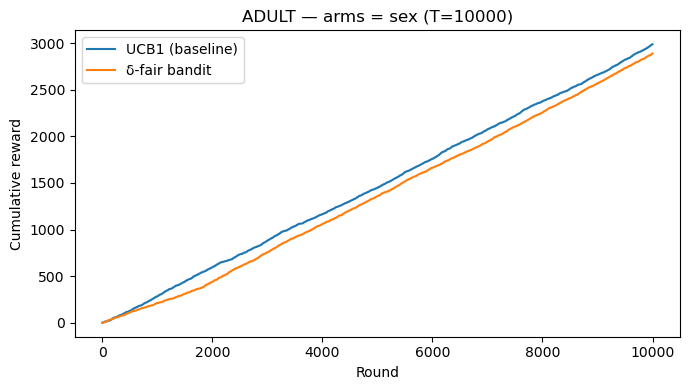

,UCB1,delta_fair
group,,
Female,0.0357,0.0934
Male,0.9643,0.9066


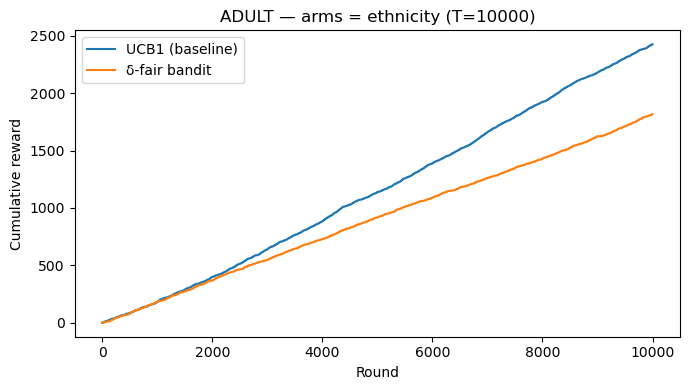

,UCB1,delta_fair
group,,
Amer-Indian-Eskimo,0.0439,0.1795
Asian-Pac-Islander,0.6418,0.2173
Black,0.0421,0.1874
Other,0.0402,0.2059
White,0.2320,0.2099


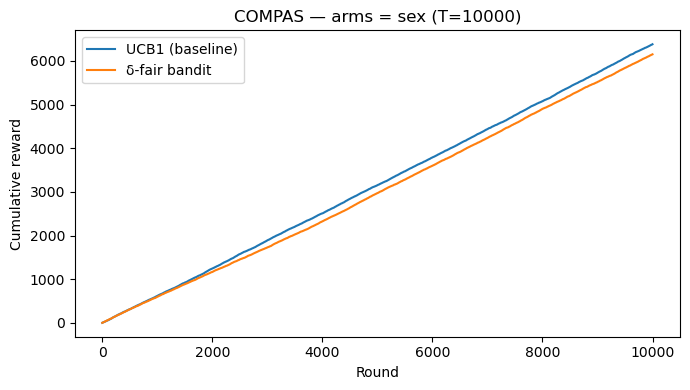

,UCB1,delta_fair
group,,
Female,0.9408,0.8073
Male,0.0592,0.1927


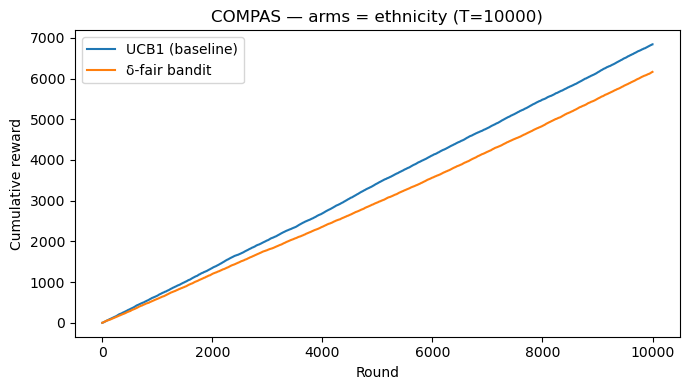

,UCB1,delta_fair
group,,
African-American,0.0215,0.1125
Asian,0.6602,0.1947
Caucasian,0.0655,0.2031
Hispanic,0.1088,0.2014
Native American,0.0214,0.0852
Other,0.1226,0.2031


Saved Exp A logs in: C:\Users\jmjn\Desktop\MA2\thesis\JM-Git\Fairness-JM-JN\results\dev


In [5]:
# Run Experiment A (Group-as-arm bandit) on Adult + COMPAS

T = CFG.T_group_bandit
delta = CFG.delta_fair
seed0 = CFG.seed0
adult_df = load_adult()
compas_df = load_compas()

DATASETS_A = {
    "adult": {
        "df": adult_df,
        "label_col": "income",
        "label_to_reward_fn": to_binary_income,
        "sens_cols": ["sex", "race"],
    },
    "compas": {
        "df": compas_df,
        "label_col": "two_year_recid",
        "label_to_reward_fn": compas_reward_from_recid,  # reward=1 for non-recid
        "sens_cols": ["sex", "race"],
    },
}

def _rolling_mean(x, w: int = 250) -> np.ndarray:
    return pd.Series(np.asarray(x, dtype=float)).rolling(window=w, min_periods=1).mean().to_numpy()

results_A: dict = {}

for ds_name, spec in DATASETS_A.items():
    df = spec["df"].copy()
    label_col = spec["label_col"]
    label_to_reward_fn = spec["label_to_reward_fn"]

    for sens_col in spec["sens_cols"]:
        if sens_col not in df.columns:
            print(f"[WARN] {ds_name}: missing {sens_col} — skipped.")
            continue

        dff = df.dropna(subset=[sens_col, label_col]).copy()
        uniq = dff[sens_col].astype(str).unique().tolist()
        K = len(uniq)
        if K < 2:
            print(f"[WARN] {ds_name}/{sens_col}: need >=2 groups, got {K} — skipped.")
            continue

        ucb = UCB1(n_arms=K)
        fair = DeltaFairBandit(n_arms=K, delta=delta, seed=seed0)

        out_ucb = simulate_group_bandit(dff, sens_col, label_col, label_to_reward_fn, ucb, T=T, seed=seed0)
        out_fair = simulate_group_bandit(dff, sens_col, label_col, label_to_reward_fn, fair, T=T, seed=seed0 + 1)
        results_A[(ds_name, sens_col)] = (out_ucb, out_fair)

        plot_group_bandit_report(out_ucb, out_fair, title=f"{ds_name.upper()} — arms = {display_sensitive(sens_col)} (T={T})")
        if CFG.run_mode == "full":
            w = 250
            plt.figure(figsize=(7, 3.5))
            plt.plot(_rolling_mean(out_ucb["rewards"], w=w), label=f"UCB1 (rolling mean, w={w})")
            plt.plot(_rolling_mean(out_fair["rewards"], w=w), label=f"δ-fair (rolling mean, w={w})")
            plt.xlabel("Round")
            plt.ylabel("Reward (smoothed)")
            plt.title(f"Instantaneous reward — {ds_name.upper()} / {display_sensitive(sens_col)}")
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Save logs
        out_ucb["logs"].to_csv(CFG.results_dir / f"A_{ds_name}_groupbandit_ucb1_{sens_col}.csv", index=False)
        out_fair["logs"].to_csv(CFG.results_dir / f"A_{ds_name}_groupbandit_deltafair_{sens_col}.csv", index=False)

print(f"Saved Exp A logs in: {CFG.results_dir.resolve()}")


## Experiment A — Standard MAB (UCB1 vs δ-fair)

Interpretation:
- The **cumulative reward** curve reflects utility (label-based reward).
- The selection table shows **exposure** per group (how often each group/arm is selected).


## 5) Experiment B — Contextual MAB (LinUCB vs FairLinUCB_DP)

In this experiment, we move from a standard multi-armed bandit to a **contextual bandit** setting, where each round provides a feature vector \(x_t\) and the learner must choose an action \(a_t \in \{0,1\}\) (binary decision). We compare a baseline **LinUCB** policy against **FairLinUCB\_DP**, which adds a demographic-parity–oriented regularization to reduce selection-rate disparities across sensitive groups.

Interpretation:
- The **reward/accuracy** measures utility (correct decision \(a_t = y_t\)).
- The **DP gap** tracks exposure/selection disparity across groups (lower is better).
- **EO gap** and **PPV gap** quantify error-based fairness disparities; they may move in a different direction than DP under a DP constraint.
- Results are reported as **mean ± 95% CI across multiple seeds** (Adult and COMPAS), to assess robustness.


In [6]:
# Optimization: maintain A^{-1} with Sherman–Morrison updates (O(d²) per step).
class LinUCB:
    """Linear UCB for binary actions {0,1} with ridge regularization."""

    def __init__(self, d: int, alpha: float = 1.0, lam: float = 1.0, n_actions: int = 2):
        self.d = int(d)
        self.alpha = float(alpha)
        self.lam = float(lam)
        self.n_actions = int(n_actions)
        self.A_inv = [np.eye(self.d, dtype=np.float32) / self.lam for _ in range(self.n_actions)]
        self.b = [np.zeros(self.d, dtype=np.float32) for _ in range(self.n_actions)]

    def _theta(self, a: int) -> np.ndarray:
        return self.A_inv[a] @ self.b[a]

    def select(self, x: np.ndarray) -> int:
        x = np.asarray(x, dtype=np.float32)
        scores = np.zeros(self.n_actions, dtype=np.float32)
        for a in range(self.n_actions):
            theta = self._theta(a)
            mean = float(theta @ x)
            var = float(x @ (self.A_inv[a] @ x))
            scores[a] = mean + self.alpha * np.sqrt(max(var, 0.0))
        return int(np.argmax(scores))

    def update(self, x: np.ndarray, action: int, reward: float) -> None:
        x = np.asarray(x, dtype=np.float32)
        a = int(action)
        r = float(reward)
        Ainv = self.A_inv[a]
        Ax = Ainv @ x
        denom = 1.0 + float(x @ Ax)
        self.A_inv[a] = Ainv - np.outer(Ax, Ax) / denom
        self.b[a] += r * x


class FairLinUCB_DP(LinUCB):
    """
    LinUCB with a soft demographic-parity (DP) penalty.

    Intuition:
      - The policy selects actions using LinUCB scores,
      - then adds a penalty term that discourages deviations from target selection parity across groups.
    """

    def __init__(
        self,
        d: int,
        groups: np.ndarray,
        alpha: float = 1.0,
        lam: float = 1.0,
        tau: float = 0.02,
        lambda_fair: float = 2.0,
        n_actions: int = 2,
    ):
        super().__init__(d=d, alpha=alpha, lam=lam, n_actions=n_actions)
        self.groups_all = np.asarray(groups).astype(str)
        self.uniq_groups = np.unique(self.groups_all)
        self.tau = float(tau)
        self.lambda_fair = float(lambda_fair)

        # Track (group, action) counts to estimate selection rates
        self.count_g = {g: 0 for g in self.uniq_groups}
        self.count_g1 = {g: 0 for g in self.uniq_groups}  # action==1 counts

    def _dp_penalty(self, g: str, action: int) -> float:
        """Penalty to reduce DP gap for action==1 selection."""
        if action != 1:
            return 0.0

        # current rates
        rates = []
        for gg in self.uniq_groups:
            den = max(1, self.count_g[gg])
            rates.append(self.count_g1[gg] / den)
        max_rate = max(rates)
        min_rate = min(rates)
        gap = max_rate - min_rate

        # penalize if over tau
        excess = max(0.0, gap - self.tau)
        return self.lambda_fair * excess

    def select(self, x: np.ndarray, group: str) -> int:
        x = np.asarray(x, dtype=np.float32)
        group = str(group)

        scores = np.zeros(self.n_actions, dtype=np.float32)
        for a in range(self.n_actions):
            theta = self._theta(a)
            mean = float(theta @ x)
            var = float(x @ (self.A_inv[a] @ x))
            ucb = mean + self.alpha * np.sqrt(max(var, 0.0))
            scores[a] = ucb - self._dp_penalty(group, a)

        return int(np.argmax(scores))

    def update(self, x: np.ndarray, group: str, action: int, reward: float) -> None:
        group = str(group)
        super().update(x, action, reward) # Update LinUCB parameters
        self.count_g[group] = self.count_g.get(group, 0) + 1 # Update group counts
        if int(action) == 1:
            self.count_g1[group] = self.count_g1.get(group, 0) + 1


### COMPAS preprocessing

For COMPAS we keep the original fields but:
- filter to the standard ProPublica subset,
- binarize ethnicity as **Caucasian vs Non-Caucasian** (`race_binary`) for stability in fairness metrics.


In [7]:
# COMPAS minimal preprocessing
def clean_compas_minimal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Minimal COMPAS cleaning aligned with the ProPublica analysis subset.
    Keeps a stable set of features and target.
    """
    df = df.copy()
    keep_cols = [
        "sex", "race", "age", "juv_fel_count", "juv_misd_count", "juv_other_count",
        "priors_count", "c_charge_degree", "two_year_recid"
    ]
    df = df[keep_cols].dropna()

    df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce").fillna(0).astype(int)
    df["sex"] = df["sex"].astype(str)
    df["race"] = df["race"].astype(str)
    df["c_charge_degree"] = df["c_charge_degree"].astype(str)
    return df


def binarize_race_compas(group: np.ndarray) -> np.ndarray:
    """Binary ethnicity grouping for stability: Caucasian vs Non-Caucasian."""
    g = np.asarray(group).astype(str)
    return np.where(g == "Caucasian", "Caucasian", "Non-Caucasian")


# Contextual feature builders
def prepare_adult_contextual(df: pd.DataFrame, sensitive_col: str):
    """Adult features: one-hot encode all non-sensitive features."""
    dff = df.dropna(subset=[sensitive_col, "income"]).copy()

    y = to_binary_income(dff["income"])
    group = dff[sensitive_col].astype(str).to_numpy()

    # Drop sensitive + label
    X_raw = dff.drop(columns=["income", sensitive_col]).copy()

    # One-hot encode categoricals; keep numeric columns
    X = pd.get_dummies(X_raw, drop_first=True)
    feat_names = X.columns.tolist()
    X = X.to_numpy(dtype=np.float32)

    return X, y, group, feat_names


def prepare_compas_contextual(df: pd.DataFrame, sensitive_col: str, n_hash: Optional[int] = None):
    """
    COMPAS features:
      - numeric: age, priors, juvenile counts
      - hashed categorical tokens: sex, race, c_charge_degree
    Sensitive attributes are excluded from features to avoid leakage.
    """
    n_hash = int(n_hash or CFG.compas_hash_features)
    dff = clean_compas_minimal(df)
    dff = dff.dropna(subset=[sensitive_col, "two_year_recid"]).copy()

    # Target: two_year_recid (0/1)
    y = dff["two_year_recid"].astype(int).to_numpy()
    group = dff[sensitive_col].astype(str).to_numpy()

    # Numeric features
    num_cols = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
    X_num = dff[num_cols].to_numpy(dtype=np.float32)

    # Categorical tokens (exclude sensitive + label + both sensitive columns)
    drop_cols = {"two_year_recid", sensitive_col, "race", "sex"}
    cat_cols = [c for c in ["sex", "race", "c_charge_degree"] if c not in drop_cols]

    token_dicts = []
    for _, row in dff[cat_cols].iterrows():
        d = {}
        for c in cat_cols:
            d[f"{c}={row[c]}"] = 1
        token_dicts.append(d)

    hasher = FeatureHasher(n_features=n_hash, input_type="dict", alternate_sign=False)
    X_cat = hasher.transform(token_dicts).toarray().astype(np.float32)  # dense (n, n_hash)

    X = np.concatenate([X_num, X_cat], axis=1).astype(np.float32)
    feat_names = [*num_cols, *[f"hash_{i}" for i in range(n_hash)]]
    return X, y, group, feat_names, hasher


### Experiment B (contextual bandit with fairness)

We evaluate LinUCB vs FairLinUCB\_DP on **Adult** and **COMPAS** for:
- `sex`
- `race` (**ethnicity**)
- COMPAS only: `race_binary` (**ethnicity_binary**, Caucasian vs Non-Caucasian)


In [8]:
adult_df = load_adult()
compas_df = load_compas()

print("Adult — 'sex' categories:", sorted(adult_df["sex"].dropna().astype(str).unique().tolist()))
print("Adult — 'race' (ethnicity) categories:", sorted(adult_df["race"].dropna().astype(str).unique().tolist()))

compas_min = clean_compas_minimal(compas_df)
print("\nCOMPAS — 'sex' categories:", sorted(compas_min["sex"].dropna().astype(str).unique().tolist()))
print("COMPAS — 'race' (ethnicity) categories:", sorted(compas_min["race"].dropna().astype(str).unique().tolist()))

compas_min["race_binary"] = np.where(compas_min["race"].astype(str) == "Caucasian", "Caucasian", "Non-Caucasian")
print("\nCOMPAS — 'race_binary' categories:", sorted(compas_min["race_binary"].unique().tolist()))
display(compas_min["race_binary"].value_counts(dropna=False).to_frame("count"))


Adult — 'sex' categories: ['Female', 'Male']
Adult — 'race' (ethnicity) categories: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

COMPAS — 'sex' categories: ['Female', 'Male']
COMPAS — 'race' (ethnicity) categories: ['African-American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other']

COMPAS — 'race_binary' categories: ['Caucasian', 'Non-Caucasian']


,count
race_binary,
Non-Caucasian,4760
Caucasian,2454


### Run Experiment B (Adult + COMPAS) with mean ± 95% CI over multiple seeds


In [9]:
# Experiment B (CMAB): multi-seed evaluation with mean ± 95% CI
# Datasets: Adult + COMPAS

adult_df = load_adult()
compas_df = load_compas()

# Parameters
T = CFG.T_contextual
seed0 = CFG.seed0
alpha = CFG.alpha_linucb
lam_ridge = CFG.lambda_ridge
tau = CFG.dp_tau
lambda_fair = CFG.dp_lambda
seeds = [seed0 + i for i in range(CFG.n_seeds)]  # dev: few seeds; full: >=10 seeds

# Fixed-index runner so both algos see identical contexts each seed
def run_contextual_bandit_fixed_indices(X, y, group, policy, idx_seq: np.ndarray) -> pd.DataFrame:
    """Run a contextual bandit policy on (X,y,group) using a fixed sequence of indices for T rounds."""
    logs = []
    for t, i in enumerate(idx_seq):
        x = X[i]
        yt = int(y[i])
        g = group[i]

        if isinstance(policy, FairLinUCB_DP):
            a = int(policy.select(x, g))
            r = float(a == yt)
            policy.update(x, g, a, r)
        else:
            a = int(policy.select(x))
            r = float(a == yt)
            policy.update(x, a, r)

        logs.append((t, i, g, yt, a, r))
    return pd.DataFrame(logs, columns=["t", "i", "group", "y_true", "action", "reward"])


datasets = {
    "adult": adult_df,
    "compas": compas_df,
}

summary_rows = []
SAVE_DETAILED_LOGS = True

for ds_name, ds_df in datasets.items():
    for sens_col in ["sex", "race"]:
        if sens_col not in ds_df.columns:
            print(f"[WARN] {ds_name}: missing {sens_col}, skipped")
            continue

        if ds_name == "adult":
            X, y, group, feat_names = prepare_adult_contextual(ds_df, sensitive_col=sens_col)
            group_bin_full = None

        elif ds_name == "compas":
            X, y, group, feat_names, _ = prepare_compas_contextual(ds_df, sensitive_col=sens_col)
            group_bin_full = binarize_race_compas(group) if sens_col == "race" else None

        else:
            raise ValueError(ds_name)

        n, d = X.shape

        for seed in seeds:
            rng = np.random.default_rng(seed)
            idx_seq = rng.integers(0, n, size=T)

            # Baseline
            lin = LinUCB(d=d, alpha=alpha, lam=lam_ridge)
            logs_lin = run_contextual_bandit_fixed_indices(X, y, group, lin, idx_seq)

            # Fair
            fair = FairLinUCB_DP(
                d=d,
                groups=group,
                alpha=alpha,
                lam=lam_ridge,
                tau=tau,
                lambda_fair=lambda_fair,
            )
            logs_fair = run_contextual_bandit_fixed_indices(X, y, group, fair, idx_seq)

            # Metrics
            m_lin = summarize_metrics(logs_lin["y_true"].to_numpy(),
                                      logs_lin["action"].to_numpy(),
                                      logs_lin["group"].to_numpy())
            m_fair = summarize_metrics(logs_fair["y_true"].to_numpy(),
                                       logs_fair["action"].to_numpy(),
                                       logs_fair["group"].to_numpy())

            summary_rows.append({"dataset": ds_name, "sensitive": sens_col, "method": "LinUCB", "seed": seed, **m_lin})
            summary_rows.append({"dataset": ds_name, "sensitive": sens_col, "method": "FairLinUCB_DP", "seed": seed, **m_fair})

            # COMPAS
            if ds_name == "compas" and sens_col == "race":
                gi_lin = group_bin_full[logs_lin["i"].to_numpy()]
                gi_fair = group_bin_full[logs_fair["i"].to_numpy()]

                m_lin_bin = summarize_metrics(logs_lin["y_true"].to_numpy(),
                                              logs_lin["action"].to_numpy(),
                                              gi_lin)
                m_fair_bin = summarize_metrics(logs_fair["y_true"].to_numpy(),
                                               logs_fair["action"].to_numpy(),
                                               gi_fair)

                summary_rows.append({"dataset": ds_name, "sensitive": "race_binary", "method": "LinUCB", "seed": seed, **m_lin_bin})
                summary_rows.append({"dataset": ds_name, "sensitive": "race_binary", "method": "FairLinUCB_DP", "seed": seed, **m_fair_bin})

            # Save detailed logs once per (dataset, sens_col, method) for bootstrap tables
            if SAVE_DETAILED_LOGS and seed == seeds[0]:
                logs_lin.to_csv(CFG.results_dir / f"B_{ds_name}_linucb_{sens_col}.csv", index=False)
                logs_fair.to_csv(CFG.results_dir / f"B_{ds_name}_fairlinucb_{sens_col}.csv", index=False)

summary = pd.DataFrame(summary_rows)
display(summary.head())

# Aggregate: mean ± 95% CI across seeds
out = []
for ds_name in summary["dataset"].unique():
    for sens_col in summary[summary["dataset"] == ds_name]["sensitive"].unique():
        for method in summary["method"].unique():
            sub = summary[(summary["dataset"] == ds_name) &
                          (summary["sensitive"] == sens_col) &
                          (summary["method"] == method)]
            if sub.empty:
                continue
            for metric in ["accuracy", "DP_gap", "EO_gap", "PPV_gap"]:
                mu, lo, hi = mean_ci(sub[metric].to_numpy(), alpha=0.05)
                out.append({
                    "dataset": ds_name,
                    "sensitive": sens_col,
                    "method": method,
                    "metric": metric,
                    "mean": mu,
                    "ci_low": lo,
                    "ci_high": hi,
                    "n_seeds": len(sub),
                })

report_ci = pd.DataFrame(out).sort_values(["dataset", "sensitive", "method", "metric"])
display(report_ci)

# Save
prefix = "full_" if CFG.run_mode == "full" else ""
report_ci.to_csv(CFG.results_dir / f"{prefix}CMAB_multiseed_metrics_ci_adult_compas.csv", index=False)
summary.to_csv(CFG.results_dir / f"{prefix}CMAB_multiseed_metrics_perseed_adult_compas.csv", index=False)

print(f"Saved in {CFG.results_dir.resolve()}")


,dataset,sensitive,method,seed,accuracy,DP_gap,EO_gap,PPV_gap
0,adult,sex,LinUCB,42,0.8052,0.187734,0.168069,0.206491
1,adult,sex,FairLinUCB_DP,42,0.8004,0.149419,0.194593,0.260502
2,adult,sex,LinUCB,43,0.7662,0.167940,0.200319,0.251744
3,adult,sex,FairLinUCB_DP,43,0.7718,0.128169,0.168979,0.285037
4,adult,sex,LinUCB,44,0.8124,0.201860,0.138877,0.174723


,dataset,sensitive,method,metric,mean,ci_low,ci_high,n_seeds
13,adult,race,FairLinUCB_DP,DP_gap,0.181000,0.150862,0.219175,3
14,adult,race,FairLinUCB_DP,EO_gap,0.378805,0.216788,0.528137,3
15,adult,race,FairLinUCB_DP,PPV_gap,0.674617,0.503064,0.782095,3
12,adult,race,FairLinUCB_DP,accuracy,0.791200,0.769390,0.809100,3
9,adult,race,LinUCB,DP_gap,0.211078,0.172787,0.258649,3
10,adult,race,LinUCB,EO_gap,0.403218,0.286179,0.491866,3
11,adult,race,LinUCB,PPV_gap,0.378784,0.248259,0.458779,3
8,adult,race,LinUCB,accuracy,0.796933,0.769270,0.814680,3
5,adult,sex,FairLinUCB_DP,DP_gap,0.141213,0.129063,0.149250,3
6,adult,sex,FairLinUCB_DP,EO_gap,0.162249,0.125464,0.193312,3


Saved in C:\Users\jmjn\Desktop\MA2\thesis\JM-Git\Fairness-JM-JN\results\dev


## Experiment B — CMAB (LinUCB vs FairLinUCB_DP)

We report **mean ± 95% CI across seeds** for:
- accuracy
- DP gap
- EO gap
- PPV gap


### (Optional) Dev vs Full consistency check

This section is only useful as a sanity check to verify that **directional effects** (e.g., DP gap decreases) are stable when switching from `dev` to `full`.


In [10]:
# plot CMAB mean ± 95% CI (FULL only)
if CFG.run_mode != "full":
    print("RUN_MODE is 'dev' -> skipping thesis figures. Set RUN_MODE='full' to generate them.")
else:
    RESDIR = CFG.results_dir
    CI_PATH = RESDIR / "full_CMAB_multiseed_metrics_ci_adult_compas.csv"
    if not CI_PATH.exists():
        raise FileNotFoundError(f"Expected FULL CI file not found: {CI_PATH}")

    datasets = ["adult", "compas"]
    metrics = ["accuracy", "DP_gap", "EO_gap", "PPV_gap"]
    sens_order = ["race", "race_binary", "sex"]
    methods = ["LinUCB", "FairLinUCB_DP"]
    offsets = {"LinUCB": -0.12, "FairLinUCB_DP": 0.12}

    titles_metric = {"accuracy": "ACCURACY", "DP_gap": "DP GAP", "EO_gap": "EO GAP", "PPV_gap": "PPV GAP"}
    ylabels_metric = {"accuracy": "accuracy", "DP_gap": "DP gap", "EO_gap": "EO gap", "PPV_gap": "PPV gap"}

    df_ci = pd.read_csv(CI_PATH)
    df_ci = df_ci[df_ci["method"].isin(methods)].copy()

    fig, axes = plt.subplots(nrows=len(metrics), ncols=len(datasets), figsize=(14, 14), sharex=False)

    for i, metric in enumerate(metrics):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            sub = df_ci[(df_ci["dataset"] == dataset) & (df_ci["metric"] == metric)].copy()

            if sub.empty:
                ax.set_title(f"{titles_metric[metric]} ({dataset}) — no data")
                ax.axis("off")
                continue

            sens_present = [s for s in sens_order if s in sub["sensitive"].astype(str).unique().tolist()]
            x = np.arange(len(sens_present))

            for method in methods:
                sm = sub[sub["method"] == method].set_index("sensitive").reindex(sens_present)
                y = sm["mean"].to_numpy(dtype=float)

                yerr_low = y - sm["ci_low"].to_numpy(dtype=float)
                yerr_high = sm["ci_high"].to_numpy(dtype=float) - y
                yerr = np.vstack([yerr_low, yerr_high])

                ax.errorbar(
                    x + offsets[method],
                    y,
                    yerr=yerr,
                    fmt="o",
                    capsize=5,
                    label=method if (i == 0 and j == 0) else None,
                )

            ax.set_title(f"{titles_metric[metric]} ({dataset}) — FULL")
            ax.set_ylabel(ylabels_metric[metric])
            ax.grid(True, axis="y", alpha=0.3)

            ax.set_xticks(x)
            ax.set_xticklabels([display_sensitive(s) for s in sens_present])
            ax.set_xlabel("Sensitive attribute")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        axes[0, 0].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

RUN_MODE is 'dev' -> skipping thesis figures. Set RUN_MODE='full' to generate them.


### FULL CMAB results (Adult + COMPAS)

The plots above show mean ± 95% CI over seeds for **utility (accuracy)** and multiple fairness gaps:
- DP gap (demographic parity)
- EO gap (equalized odds)
- PPV gap (predictive parity)

In COMPAS, we report both **multi-group ethnicity** (`race`) and **binary ethnicity** (`race_binary` = Caucasian vs Non-Caucasian) because multi-group gaps can be unstable when some groups are small, while a binary split is more statistically robust.
